# Actividad integradora: Segmentación por color

En esta actividad vas a tomar decisiones propias. Ya viste ejemplos guiados; ahora te toca diseñar una estrategia de segmentación, justificarla y revisar tus resultados.

## Consigna general

Podés trabajar de dos maneras:

- con una imagen de ejemplo del repositorio, o
- con `imagen_preprocesada.png` si antes completaste `007 - recuperacion y preprocesamiento de imagenes propias.ipynb`.

La meta no es solo obtener una máscara "linda", sino explicar por qué elegiste esa estrategia y qué límites encontraste.

## Qué se espera que entregues

- una imagen de entrada,
- una o más máscaras de prueba,
- una versión final segmentada,
- una breve justificación de los umbrales elegidos,
- una reflexión sobre errores, ajustes y límites del método.

## Criterios de evaluación

- claridad en la lectura de la imagen,
- justificación de parámetros,
- capacidad para comparar alternativas,
- interpretación crítica del resultado,
- uso claro del lenguaje técnico.


In [4]:
import urllib.request
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


def cargar_rgb(ruta):
    imagen_bgr = cv2.imread(str(ruta))
    return cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)


def mostrar_canales(imagen_rgb):
    rojo = imagen_rgb[:, :, 0]
    verde = imagen_rgb[:, :, 1]
    azul = imagen_rgb[:, :, 2]

    fig, axes = plt.subplots(2, 2, figsize=(10, 9))
    axes[0, 0].imshow(imagen_rgb)
    axes[0, 0].set_title("Imagen original")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(rojo, cmap="gray")
    axes[0, 1].set_title("Canal rojo")
    axes[0, 1].axis("off")

    axes[1, 0].imshow(verde, cmap="gray")
    axes[1, 0].set_title("Canal verde")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(azul, cmap="gray")
    axes[1, 1].set_title("Canal azul")
    axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()


def mostrar_histogramas(imagen_rgb):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, indice, color, titulo in zip(
        axes,
        [0, 1, 2],
        ["red", "green", "blue"],
        ["Rojo", "Verde", "Azul"],
    ):
        hist, bins = np.histogram(imagen_rgb[:, :, indice].flatten(), bins=256, range=[0, 256])
        ax.plot(bins[:-1], hist, color=color)
        ax.set_title(f"Histograma {titulo}")
        ax.set_xlim(0, 255)
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def segmentar_color(imagen_rgb, r_min, r_max, g_min, g_max, b_min, b_max):
    rojo = imagen_rgb[:, :, 0]
    verde = imagen_rgb[:, :, 1]
    azul = imagen_rgb[:, :, 2]
    mascara = (
        (rojo >= r_min) & (rojo <= r_max) &
        (verde >= g_min) & (verde <= g_max) &
        (azul >= b_min) & (azul <= b_max)
    )
    return mascara


In [2]:
archivos = {
    "flores": (
        Path("flowers.jpg"),
        "https://www.dropbox.com/s/jetlnfihles3g7k/flowers.jpg?dl=1",
    ),
    "frutos": (
        Path("frutos_rojos.png"),
        "https://www.dropbox.com/s/do6b49d10ty1dyf/frutos_rojos.png?dl=1",
    ),
}

for ruta, url in archivos.values():
    if not ruta.exists():
        urllib.request.urlretrieve(url, ruta)

if Path("imagen_preprocesada.png").exists():
    print("También está disponible: imagen_preprocesada.png")

print("Imágenes listas para la actividad.")


Imágenes listas para la actividad.


## Parte 1. Elegí una imagen y un color objetivo

Si completaste el cuaderno extra de preprocesamiento, te conviene empezar con `imagen_preprocesada.png`. Si no, podés trabajar con `flowers.jpg` o con `frutos_rojos.png`.

Antes de escribir código, anotá qué color querés segmentar y por qué te parece un buen caso para probar.


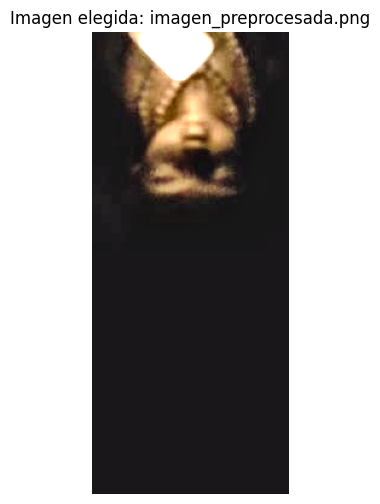

Color objetivo: La parte iluminada del centro que tiene un color amrillo/beige/marron claro (esa tonalidad, no puedo distinguer el color)


In [5]:
# Elegí la imagen con la que vas a trabajar.
if Path("imagen_preprocesada.png").exists():
    nombre_imagen = "imagen_preprocesada.png"
else:
    nombre_imagen = "flowers.jpg"  # o "frutos_rojos.png"

imagen_rgb = cargar_rgb(nombre_imagen)

# Escribí en una frase qué color querés segmentar.
color_objetivo = "La parte iluminada del centro que tiene un color amrillo/beige/marron claro (esa tonalidad, no puedo distinguer el color)"

plt.figure(figsize=(6, 6))
plt.imshow(imagen_rgb)
plt.title(f"Imagen elegida: {nombre_imagen}")
plt.axis("off")
plt.show()

print("Color objetivo:", color_objetivo)


## Parte 2. Explorá canales e histogramas

Antes de definir umbrales, mirá la imagen por canales y revisá sus histogramas. La pregunta clave es: ¿qué canal parece más útil para distinguir el color que querés aislar?


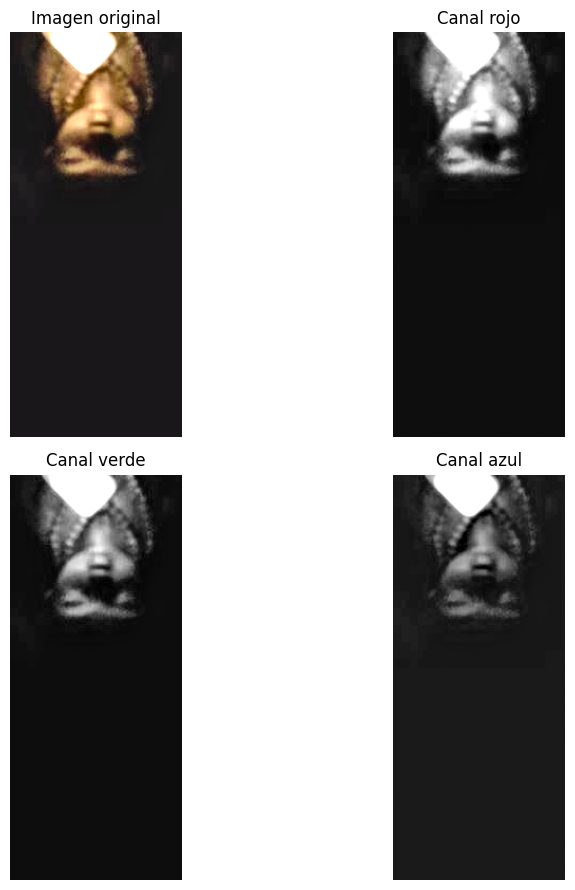

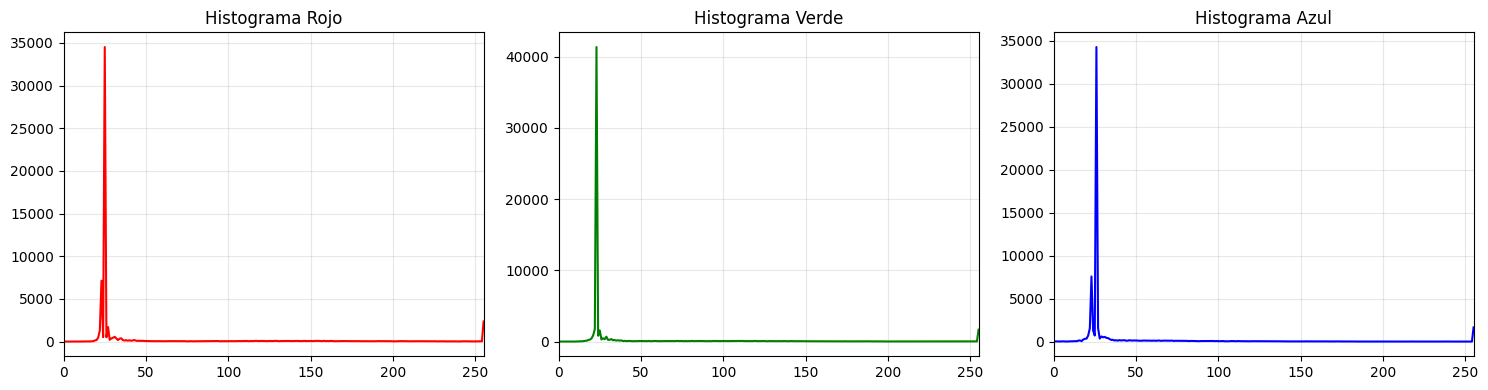

In [6]:
mostrar_canales(imagen_rgb)
mostrar_histogramas(imagen_rgb)


In [7]:
# Escribí una observación breve sobre lo que viste.
observacion = "Se observa que la mayor parte de la imagen corresponde a un fondo muy oscuro, mientras que la parte de interés aparece en tonos cálidos, claros. En los canales RGB, la proyección se distingue mejor en el canal rojo."
print(observacion)


Se observa que la mayor parte de la imagen corresponde a un fondo muy oscuro, mientras que la parte de interés aparece en tonos cálidos, claros. En los canales RGB, la proyección se distingue mejor en el canal rojo.


## Parte 3. Diseñá tu primera estrategia de segmentación

Completá los rangos mínimos y máximos para cada canal. No tienen por qué ser perfectos en el primer intento. La idea es que puedas probar, mirar y corregir.


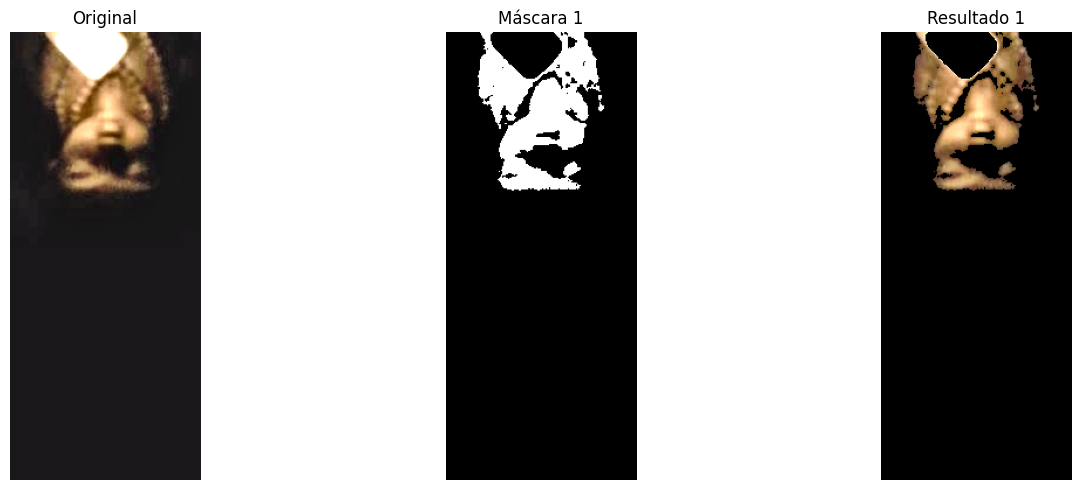

In [10]:
r_min, r_max = 90, 255
g_min, g_max = 60, 255
b_min, b_max = 35, 200

mascara_1 = segmentar_color(imagen_rgb, r_min, r_max, g_min, g_max, b_min, b_max)
resultado_1 = imagen_rgb.copy()
resultado_1[~mascara_1] = 0

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(imagen_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(mascara_1, cmap="gray")
axes[1].set_title("Máscara 1")
axes[1].axis("off")

axes[2].imshow(resultado_1)
axes[2].set_title("Resultado 1")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## Parte 4. Revisá y mejorá

Proponé una segunda estrategia. Puede cambiar solo un parámetro o varios. Después compará ambos resultados y explicá cuál conservarías.


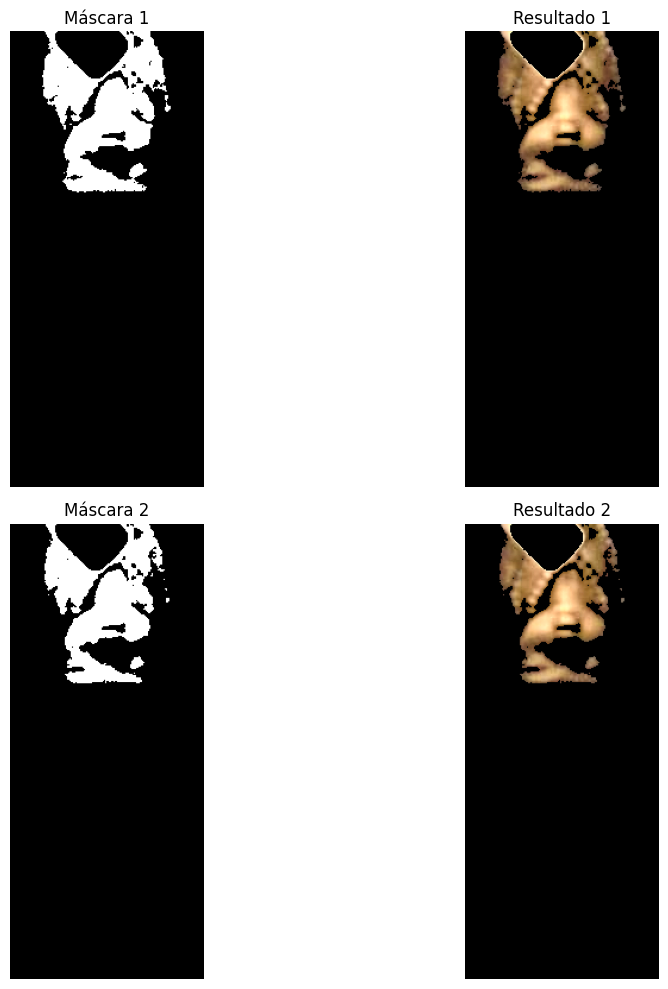

In [12]:
r_min_2, r_max_2 = 110, 255
g_min_2, g_max_2 = 75, 255
b_min_2, b_max_2 = 35, 200

mascara_2 = segmentar_color(imagen_rgb, r_min_2, r_max_2, g_min_2, g_max_2, b_min_2, b_max_2)
resultado_2 = imagen_rgb.copy()
resultado_2[~mascara_2] = 0

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(mascara_1, cmap="gray")
axes[0, 0].set_title("Máscara 1")
axes[0, 0].axis("off")

axes[0, 1].imshow(resultado_1)
axes[0, 1].set_title("Resultado 1")
axes[0, 1].axis("off")

axes[1, 0].imshow(mascara_2, cmap="gray")
axes[1, 0].set_title("Máscara 2")
axes[1, 0].axis("off")

axes[1, 1].imshow(resultado_2)
axes[1, 1].set_title("Resultado 2")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


## Parte 5. Cierre escrito

Respondé con tus palabras:

1. ¿Qué color intentaste segmentar?
2. ¿Qué canales te dieron la pista más útil?
3. ¿Qué ajustes hiciste entre la primera y la segunda estrategia?
4. ¿Qué limitaciones encontraste en este método?
5. Si tuvieras más tiempo, ¿qué mejorarías?

### Lista de control antes de entregar

- Mostré la imagen original.
- Analicé canales e histogramas.
- Probé al menos dos estrategias.
- Elegí una y la justifiqué.
- Escribí una reflexión final clara.


1. Intenté segmentar los tonos cálidos y claros, sobre todo amarillos, beige y marrones claros (o yo pienso que son esas tonalidades).
2. La pista más útil la dieron sobre todo los canales rojo y verde. En esos canales la región de interés se veía más marcada.
3. En la primera use un rango mas amplio, en la segunda trate de ajustar mas en rojo y verde. Trate de quedarme con la parte iluminada.
4. La principal limitación es que la imagen tiene poca luz y variaciones de intensidad.
5. Probaría otros espacios de color, como HSV. O probaria con otra imagen.

#### Reflexión final
La segmentación por color sirvio para separar bastante bien la zona iluminada del fondo negro. Pero como la imagen tiene poca luz el resultado no es tan bueno.


### Aca estoy probando con una imagen diferente, solo para ver como queda

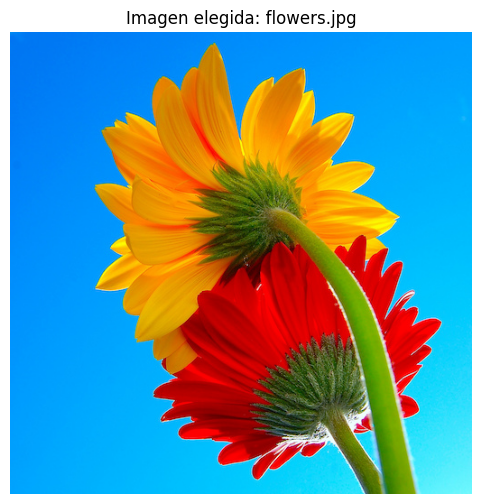

Color objetivo: Esta imagen presenta colores bien distintos.Voy a tratar de segmentar el color verde del tallo.


In [5]:
nombre_imagen_3 = "flowers.jpg"  # o "frutos_rojos.png"

imagen_rgb_3 = cargar_rgb(nombre_imagen_3)

# Escribí en una frase qué color querés segmentar.
color_objetivo_3 = "Esta imagen presenta colores bien distintos.Voy a tratar de segmentar el color verde del tallo."

plt.figure(figsize=(6, 6))
plt.imshow(imagen_rgb_3)
plt.title(f"Imagen elegida: {nombre_imagen_3}")
plt.axis("off")
plt.show()

print("Color objetivo:", color_objetivo_3)


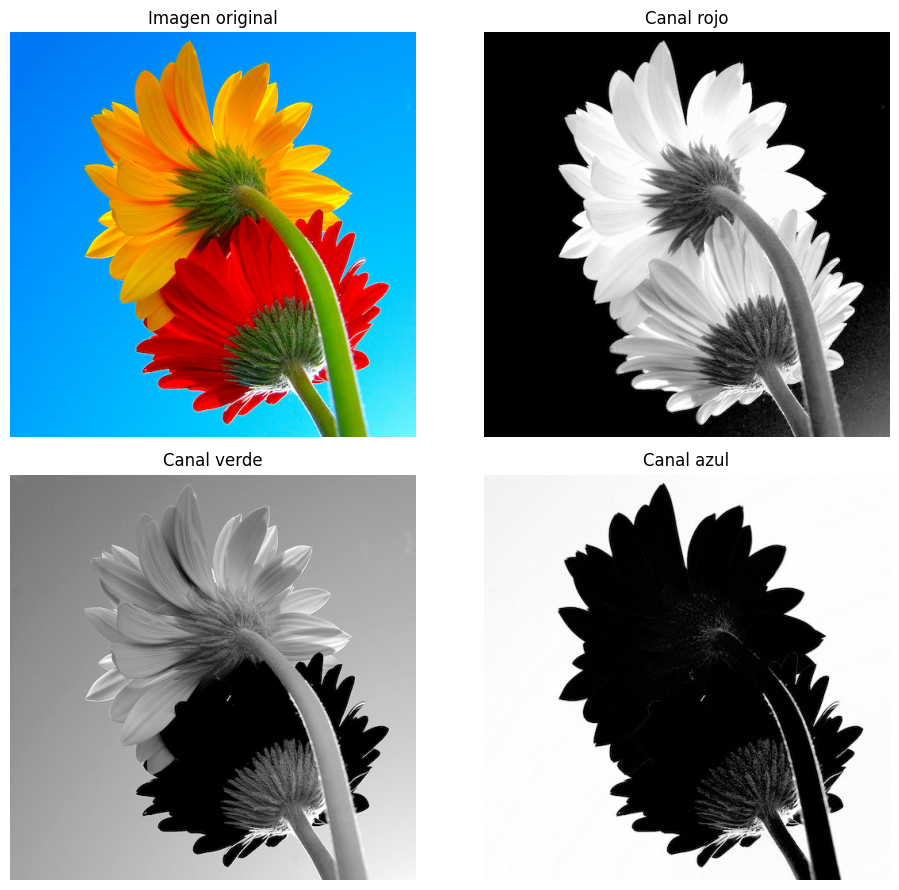

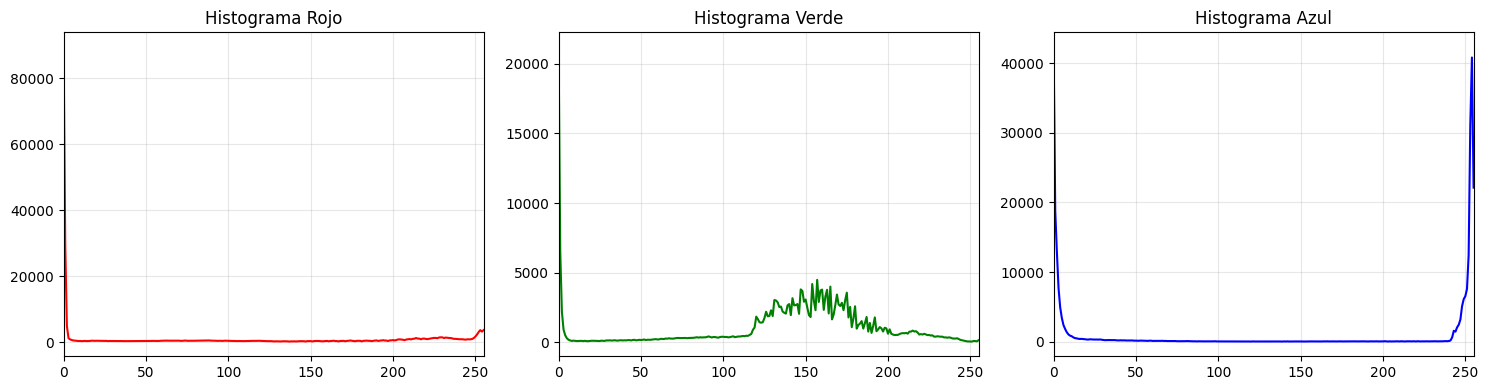

In [66]:
mostrar_canales(imagen_rgb_3)
mostrar_histogramas(imagen_rgb_3)

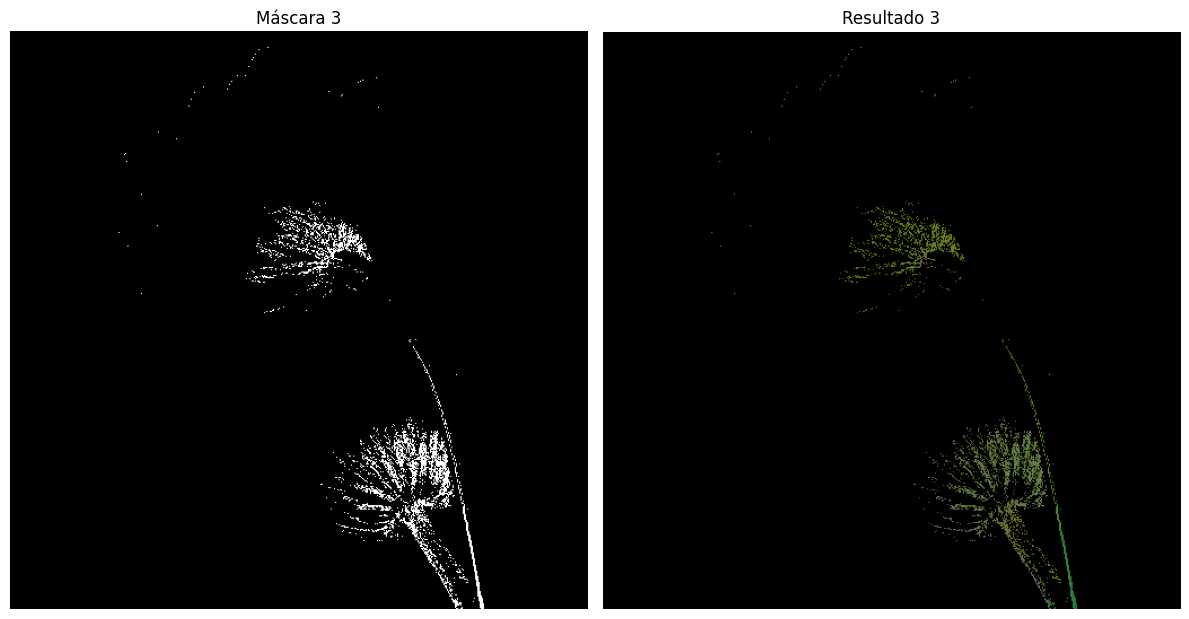

In [6]:
#r_min_3, r_max_3 = 20, 170
#g_min_3, g_max_3 = 80, 255
#b_min_3, b_max_3 = 20, 170

r_min_3, r_max_3 = 10, 120
g_min_3, g_max_3 = 95, 255
b_min_3, b_max_3 = 10, 110

mascara_3 = segmentar_color(imagen_rgb_3, r_min_3, r_max_3, g_min_3, g_max_3, b_min_3, b_max_3)
resultado_3 = imagen_rgb_3.copy()
resultado_3[~mascara_3] = 0


fig, axes = plt.subplots(1, 2, figsize=(12, 10))
axes[0].imshow(mascara_3, cmap="gray")
axes[0].set_title("Máscara 3")
axes[0].axis("off")


axes[1].imshow(resultado_3)
axes[1].set_title("Resultado 3")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Aunque visualmente se los ve muy bien, no pude separar bien en RGB. Voy a probar con HSV 

In [7]:
imagen_hsv = cv2.cvtColor(imagen_rgb_3, cv2.COLOR_RGB2HSV)

In [74]:
#print(imagen_hsv[y, x])

print(imagen_hsv[300, 350])
print(imagen_hsv[350, 360])
print(imagen_hsv[400, 370])

[  0 254 215]
[ 25 181  89]
[ 36 168  76]


Muestreo sobre algunos puntos
* primer píxel: H = 0 → está en la zona de rojo
* segundo píxel: H = 25 → está más cerca de amarillo / amarillo verdoso
* tercer píxel: H = 36 → ya entra en una zona más cercana al verde

In [8]:
h_min, h_max = 30, 50
s_min, s_max = 80, 255
v_min, v_max = 40, 255

mascara_hsv = (
    (imagen_hsv[:, :, 0] >= h_min) & (imagen_hsv[:, :, 0] <= h_max) &
    (imagen_hsv[:, :, 1] >= s_min) & (imagen_hsv[:, :, 1] <= s_max) &
    (imagen_hsv[:, :, 2] >= v_min) & (imagen_hsv[:, :, 2] <= v_max)
)

resultado_hsv = imagen_rgb_3.copy()
resultado_hsv[~mascara_hsv] = 0

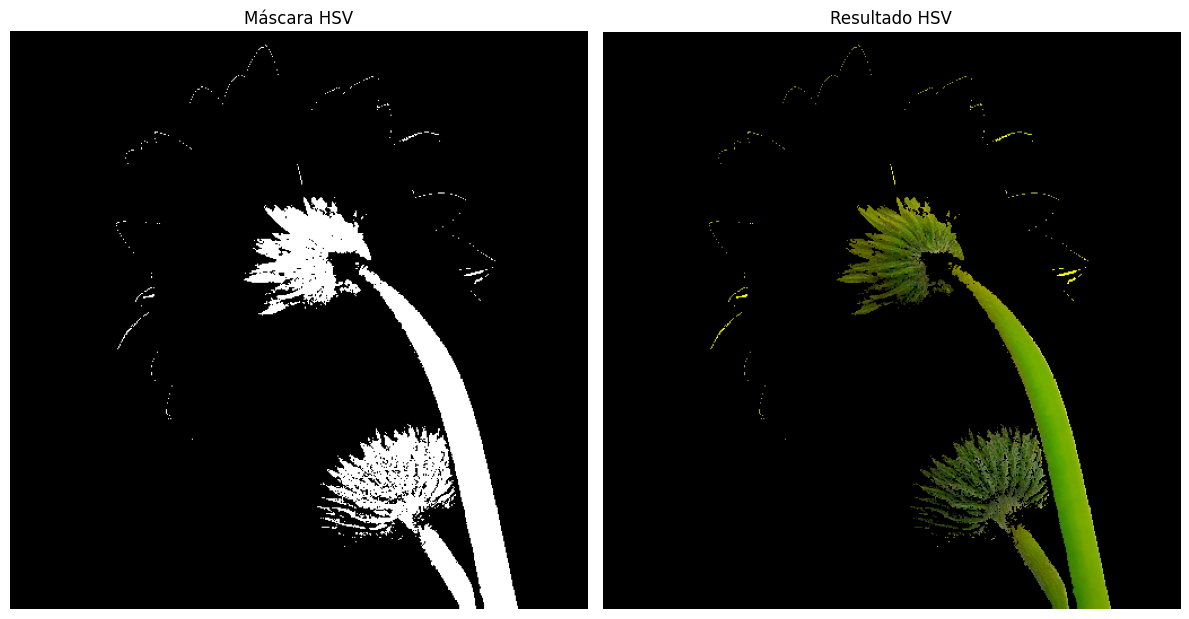

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(12, 10))

axes[0].imshow(mascara_hsv, cmap="gray")
axes[0].set_title("Máscara HSV")
axes[0].axis("off")

axes[1].imshow(resultado_hsv)
axes[1].set_title("Resultado HSV")
axes[1].axis("off")

plt.tight_layout()
plt.show()